# Dengesiz Veri ile İnme (Stroke) Tahmini — Model Karşılaştırması
## Lojistik Regresyon | Random Forest | XGBoost

**Dönem Ödevi:** Dengesiz veri setinde 3 farklı makine öğrenmesi modelinin karşılaştırmalı analizi

---
### Düzeltilen Hatalar:
| # | Hata Türü | Açıklama | Düzeltme |
|---|-----------|----------|----------|
| 1 | SYNTAX | `f-string` içinde iç içe çift tırnak | Tek tırnak kullanıldı |
| 2 | MANTIK | `cap_outliers()` → `heart_disease` kontrol ediliyordu | `stroke` olarak düzeltildi |
| 3 | DATA LEAKAGE | Scaler iki kez `fit_transform` uygulanıyordu | Tek sefere indirildi |
| 4 | TUTARSIZLIK | 2. hücrede modeller parametresiz tekrar tanımlanıyordu | Tek ana hücrede birleştirildi |

In [2]:
# ============================================================
# HÜCRE 1 — KÜTÜPHANE İMPORTLARI
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.metrics import geometric_mean_score
from xgboost import XGBClassifier

print('Tüm kütüphaneler başarıyla yüklendi.')

Tüm kütüphaneler başarıyla yüklendi.


In [3]:
# ============================================================
# HÜCRE 2 — VERİ YÜKLEME VE GENEL İSTATİSTİKLER
# ============================================================
df = pd.read_csv('dataset.csv')
print('Veri seti boyutu:', df.shape)
print(df.describe())
print('\nSütunlar:', df.columns.tolist())

Veri seti boyutu: (43400, 12)
                 id           age  hypertension  heart_disease  \
count  43400.000000  43400.000000  43400.000000   43400.000000   
mean   36326.142350     42.217894      0.093571       0.047512   
std    21072.134879     22.519649      0.291235       0.212733   
min        1.000000      0.080000      0.000000       0.000000   
25%    18038.500000     24.000000      0.000000       0.000000   
50%    36351.500000     44.000000      0.000000       0.000000   
75%    54514.250000     60.000000      0.000000       0.000000   
max    72943.000000     82.000000      1.000000       1.000000   

       avg_glucose_level           bmi        stroke  
count       43400.000000  41938.000000  43400.000000  
mean          104.482750     28.605038      0.018041  
std            43.111751      7.770020      0.133103  
min            55.000000     10.100000      0.000000  
25%            77.540000     23.200000      0.000000  
50%            91.580000     27.700000      0

In [4]:
# ============================================================
# HÜCRE 3 — DENGESİZLİK ANALİZİ
# ============================================================
def imbalanced_analysis(df, threshold=0.80):
    report = []
    for col in df.columns:
        counts = df[col].value_counts(normalize=True)
        if counts.empty:
            report.append({'Column': col, 'Unique Val': 0, 'Common %': 'N/A', 'Status': 'All Missing / Empty'})
            continue
        top_ratio = counts.iloc[0]
        report.append({
            'Column'    : col,
            'Unique Val': len(counts),
            'Common %'  : f'{top_ratio:.2%}',
            'Status'    : 'imbalanced' if top_ratio > threshold else 'balanced'
        })
    return pd.DataFrame(report)

print(imbalanced_analysis(df, threshold=0.80))

               Column  Unique Val Common %      Status
0                  id       43400    0.00%    balanced
1              gender           3   59.14%    balanced
2                 age         104    1.70%    balanced
3        hypertension           2   90.64%  imbalanced
4       heart_disease           2   95.25%  imbalanced
5        ever_married           2   64.37%    balanced
6           work_type           5   57.22%    balanced
7      Residence_type           2   50.13%    balanced
8   avg_glucose_level       12543    0.04%    balanced
9                 bmi         555    0.65%    balanced
10     smoking_status           3   53.32%    balanced
11             stroke           2   98.20%  imbalanced


In [5]:
# ============================================================
# HÜCRE 4 — AYKIRI DEĞER ANALİZİ
# ============================================================
def outlier_analysis(df):
    outlier_report = []
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        IQR = q3 - q1
        lower_bound = q1 - 1.5 * IQR
        upper_bound = q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        if outlier_count > 0:
            outlier_report.append({
                'Column'       : col,
                'Outlier Count': outlier_count,
                'Outlier %'    : f'{(outlier_count / len(df)):.2%}',
                'Lower Bound'  : round(lower_bound, 2),
                'Upper Bound'  : round(upper_bound, 2)
            })
    return pd.DataFrame(outlier_report)

print(outlier_analysis(df))

              Column  Outlier Count Outlier %  Lower Bound  Upper Bound
0       hypertension           4061     9.36%         0.00         0.00
1      heart_disease           2062     4.75%         0.00         0.00
2  avg_glucose_level           4978    11.47%        25.75       163.86
3                bmi            888     2.05%         8.65        47.45
4             stroke            783     1.80%         0.00         0.00


In [6]:
# ============================================================
# HÜCRE 5 — AYKIRI DEĞER BASKILAMA (Capping)
# ============================================================
def cap_outliers(df):
    df_capped = df.copy()
    num_cols = ['age', 'avg_glucose_level', 'bmi']
    for col in num_cols:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_capped[col] = np.where(
            df_capped[col] > upper_bound, upper_bound,
            np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
        )
    return df_capped

baskilanmis_df = cap_outliers(df)

# DÜZELTME: Hedef değişken 'stroke', 'heart_disease' değil!
print('Baskılama Sonrası Hedef Sınıf Dağılımı (stroke):')
print(baskilanmis_df['stroke'].value_counts())
print(f"\nDengesizlik Oranı: %{baskilanmis_df['stroke'].value_counts(normalize=True)[0]*100:.1f} negatif / %{baskilanmis_df['stroke'].value_counts(normalize=True)[1]*100:.1f} pozitif")

Baskılama Sonrası Hedef Sınıf Dağılımı (stroke):
stroke
0    42617
1      783
Name: count, dtype: int64

Dengesizlik Oranı: %98.2 negatif / %1.8 pozitif


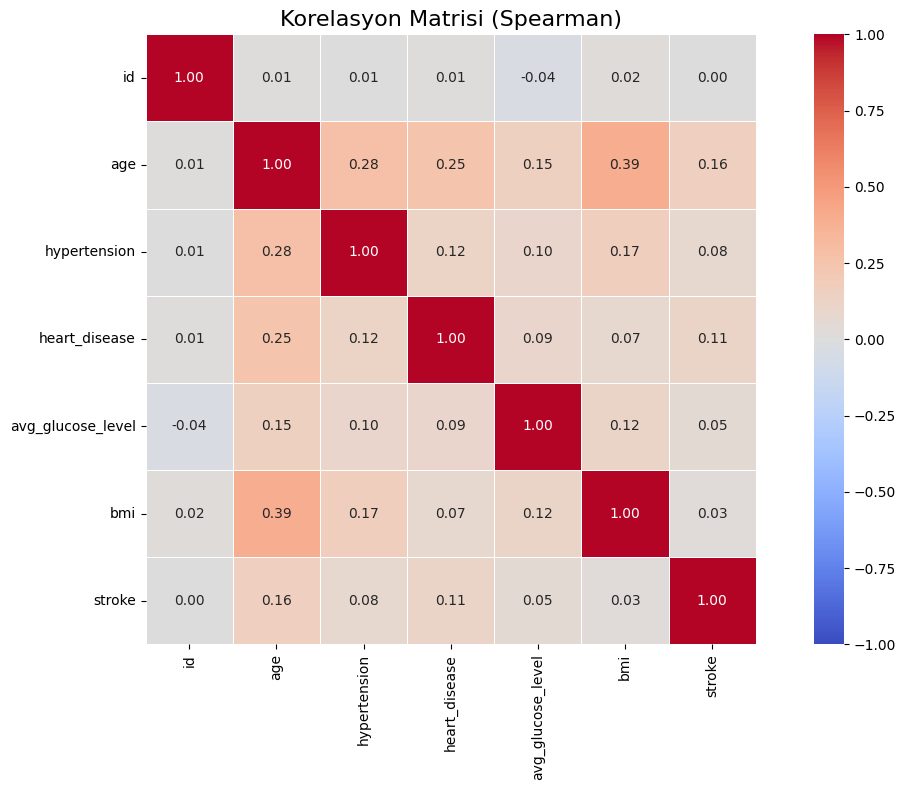

In [7]:
# ============================================================
# HÜCRE 6 — KORELASYON ISISI HARİTASI
# ============================================================
def plot_correlation_heatmap(df, method='spearman'):
    num_df = df.select_dtypes(include=[np.number])
    corr_matrix = num_df.corr(method=method)
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                vmin=-1, vmax=1, linewidths=0.5, square=True)
    plt.title(f'Korelasyon Matrisi ({method.capitalize()})', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_correlation_heatmap(baskilanmis_df, method='spearman')

── SMOTE Sonrası Eğitim Seti Dağılımı ──
  Sınıf 0: 34094 örnek
  Sınıf 1: 10228 örnek


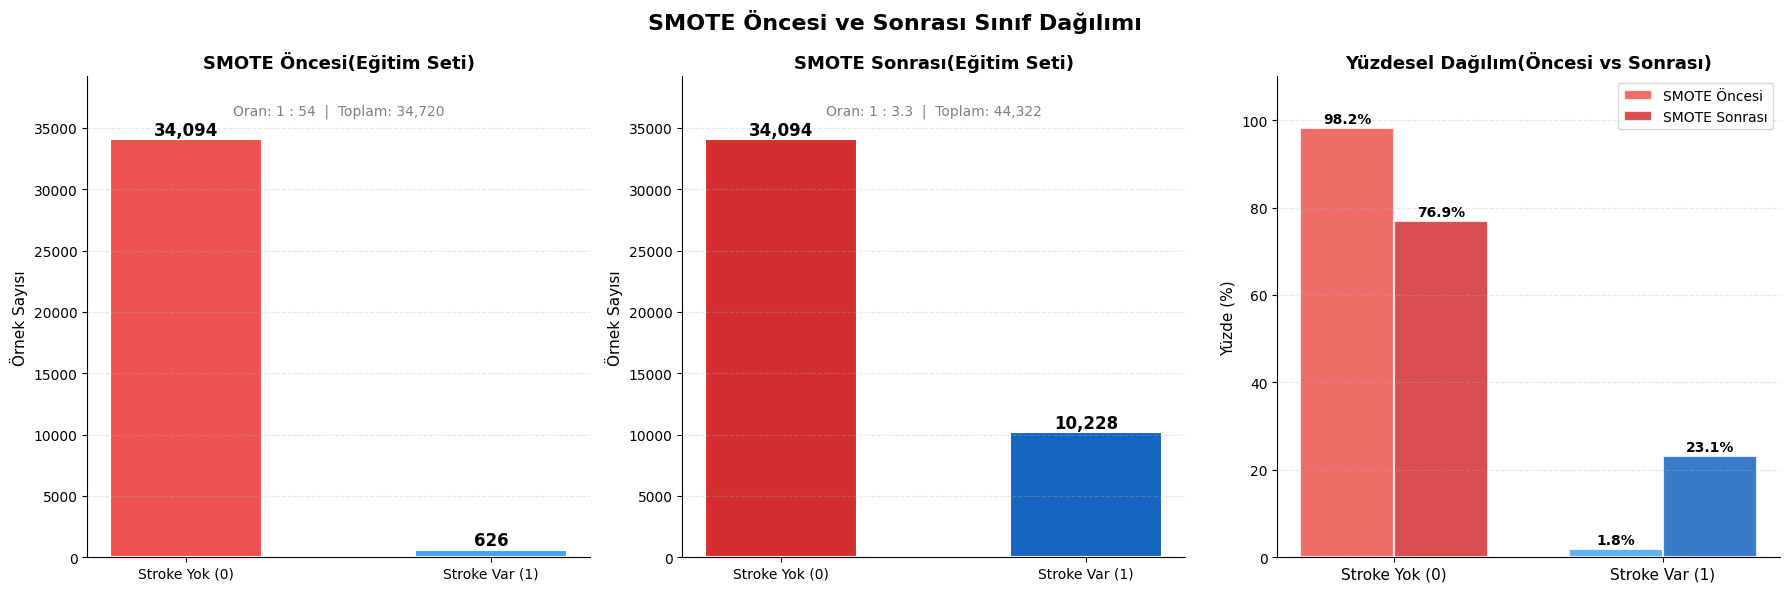


── SMOTE Sonrası Eğitim Seti Dağılımı ──
  Sınıf 0: 34,094 örnek  (76.9%)
  Sınıf 1: 10,228 örnek  (23.1%)

  Yeni azınlık / çoğunluk oranı: %30.0

XGBoost scale_pos_weight: 54.46

MODEL EĞİTİMİ VE DEĞERLENDİRME

Model: Lojistik Regresyon
G-Mean Score  : 0.6448
ROC-AUC Score : 0.7757
PR-AUC Score  : 0.0497

Classification Report:
                precision    recall  f1-score   support

Stroke Yok (0)       0.99      0.84      0.91      8523
Stroke Var (1)       0.05      0.50      0.10       157

      accuracy                           0.83      8680
     macro avg       0.52      0.67      0.50      8680
  weighted avg       0.97      0.83      0.89      8680


Model: Random Forest
G-Mean Score  : 0.6712
ROC-AUC Score : 0.8044
PR-AUC Score  : 0.0546

Classification Report:
                precision    recall  f1-score   support

Stroke Yok (0)       0.99      0.84      0.91      8523
Stroke Var (1)       0.06      0.54      0.11       157

      accuracy                           0.

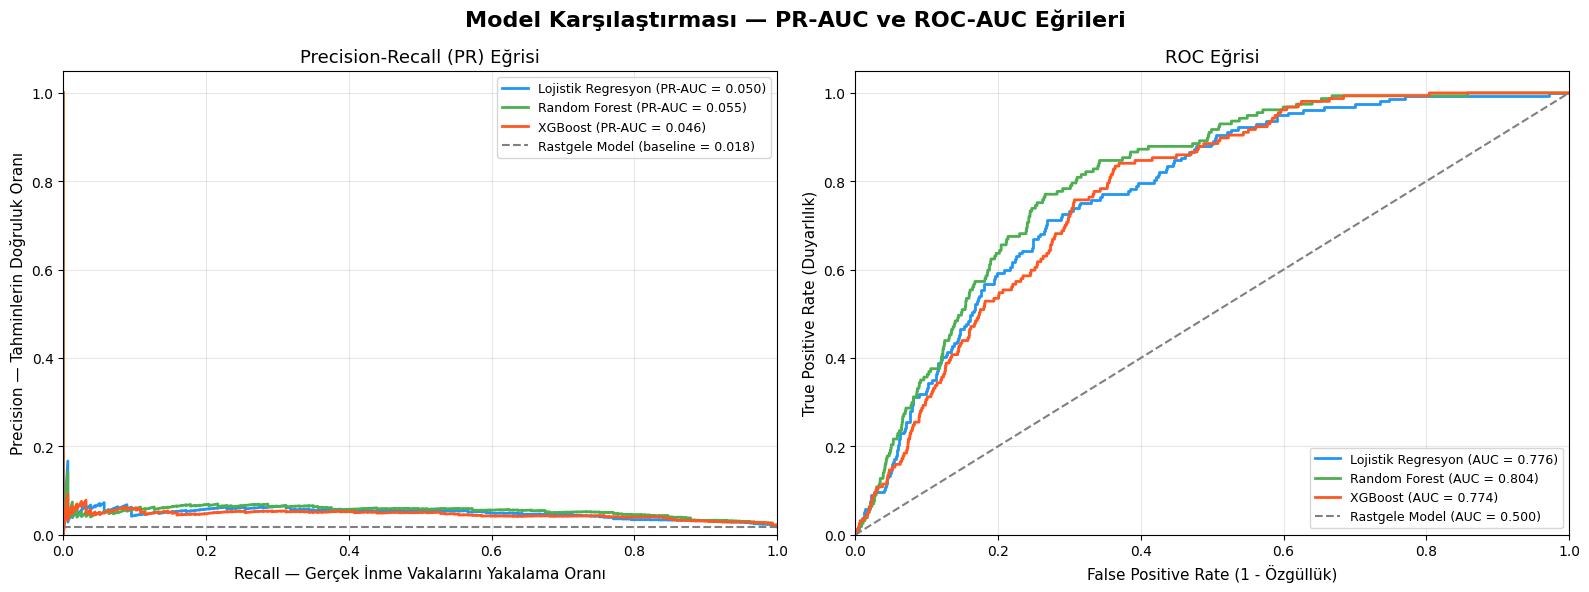

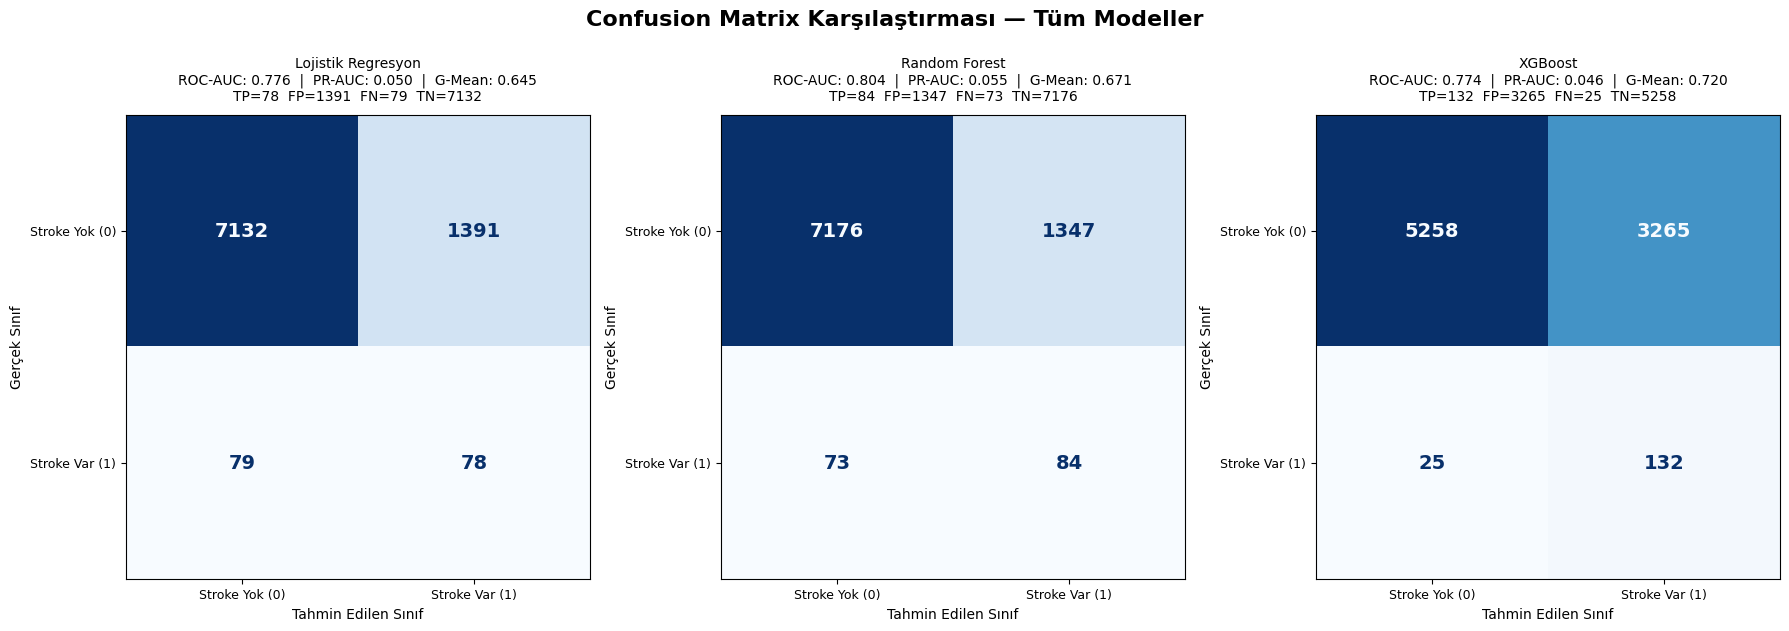


MODEL KARŞILAŞTIRMA ÖZET TABLOSU
             Model ROC-AUC PR-AUC G-Mean Recall (Stroke=1) Precision (Stroke=1)  TP (Yakalanan)  FN (Kaçırılan)
Lojistik Regresyon  0.7757 0.0497 0.6448            0.4968               0.0531              78              79
     Random Forest  0.8044 0.0546 0.6712            0.5350               0.0587              84              73
           XGBoost  0.7739 0.0464 0.7202            0.8408               0.0389             132              25

NOT: Tıbbi uygulamalarda FN (kaçırılan hasta) minimize edilmelidir.
     Bu nedenle Recall ve G-Mean metrikleri öncelikli değerlendirme kriteridir.


In [8]:
# ============================================================
# HÜCRE 7 — VERİ ÖN İŞLEME + SMOTE + MODEL EĞİTİMİ +
#           PR-AUC EĞRİSİ + ROC-AUC EĞRİSİ + CONFUSION MATRİSLERİ
#
# Dönem Ödevi Ana Hücresi — Tüm Modeller Tek Yerde
# ============================================================

# ── 1. X ve y AYRIMI ────────────────────────────────────────
X = baskilanmis_df.drop(columns=['stroke', 'id'])
y = baskilanmis_df['stroke'].values

# ── 2. EKSİK VERİ DOLDURMA ──────────────────────────────────
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
if len(numeric_cols) > 0:
    num_imputer = SimpleImputer(strategy='median')
    X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])

categorical_cols = X.select_dtypes(include=['object', 'category']).columns
if len(categorical_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

# ── 3. ENCODING ─────────────────────────────────────────────
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

# ── 4. TRAIN / TEST AYRIMI ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

# ── 5. SMOTE (İyileştirilmiş Parametreler) ─────────────────
# sampling_strategy=0.3: Azınlık sınıfını çoğunluğun %30'una çıkarır
# Tam dengeleme (1.0) bazen overfitting'e yol açar; kısmi daha sağlıklıdır
# k_neighbors=3: Küçük azınlık kümelerinde daha güvenilir sentetik örnek üretir
smote = SMOTE(sampling_strategy=0.3, k_neighbors=3, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('── SMOTE Sonrası Eğitim Seti Dağılımı ──')
unique, counts = np.unique(y_train_smote, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Sınıf {u}: {c} örnek')
    
    
before_counts = {0: np.sum(y_train == 0), 1: np.sum(y_train == 1)}
after_counts  = {0: np.sum(y_train_smote == 0), 1: np.sum(y_train_smote == 1)}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('SMOTE Öncesi ve Sonrası Sınıf Dağılımı', fontsize=16, fontweight='bold')

palette = {'before': ('#EF5350', '#42A5F5'), 'after': ('#D32F2F', '#1565C0')}

# — Sol: SMOTE Öncesi Bar —
ax = axes[0]
bars = ax.bar(['Stroke Yok (0)', 'Stroke Var (1)'],
              [before_counts[0], before_counts[1]],
              color=[palette['before'][0], palette['before'][1]],
              edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, [before_counts[0], before_counts[1]]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
total_before = before_counts[0] + before_counts[1]
ax.set_title('SMOTE Öncesi(Eğitim Seti)', fontsize=13, fontweight='bold')
ax.set_ylabel('Örnek Sayısı', fontsize=11)
ax.set_ylim(0, max(before_counts[0], after_counts[0]) * 1.15)
ax.text(0.5, 0.92, f"Oran: 1 : {before_counts[0]//before_counts[1]}  |  Toplam: {total_before:,}",
        transform=ax.transAxes, ha='center', fontsize=10, color='gray')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

# — Orta: SMOTE Sonrası Bar —
ax = axes[1]
bars = ax.bar(['Stroke Yok (0)', 'Stroke Var (1)'],
              [after_counts[0], after_counts[1]],
              color=[palette['after'][0], palette['after'][1]],
              edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, [after_counts[0], after_counts[1]]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
total_after = after_counts[0] + after_counts[1]
approx_ratio = round(after_counts[0] / after_counts[1], 1)
ax.set_title('SMOTE Sonrası(Eğitim Seti)', fontsize=13, fontweight='bold')
ax.set_ylabel('Örnek Sayısı', fontsize=11)
ax.set_ylim(0, max(before_counts[0], after_counts[0]) * 1.15)
ax.text(0.5, 0.92, f"Oran: 1 : {approx_ratio}  |  Toplam: {total_after:,}",
        transform=ax.transAxes, ha='center', fontsize=10, color='gray')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

# — Sağ: Pasta (Oran Karşılaştırması) —
ax = axes[2]
width  = 0.35
x      = np.array([0, 1])
labels = ['Stroke Yok (0)', 'Stroke Var (1)']

before_pct = [before_counts[k] / total_before * 100 for k in [0, 1]]
after_pct  = [after_counts[k]  / total_after  * 100 for k in [0, 1]]

b1 = ax.bar(x - width/2, before_pct, width, label='SMOTE Öncesi',
            color=[palette['before'][0], palette['before'][1]],
            edgecolor='white', linewidth=1.5, alpha=0.85)
b2 = ax.bar(x + width/2, after_pct,  width, label='SMOTE Sonrası',
            color=[palette['after'][0],  palette['after'][1]],
            edgecolor='white', linewidth=1.5, alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Yüzde (%)', fontsize=11)
ax.set_ylim(0, 110)
ax.set_title('Yüzdesel Dağılım(Öncesi vs Sonrası)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\n── SMOTE Sonrası Eğitim Seti Dağılımı ──")
unique, counts = np.unique(y_train_smote, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Sınıf {u}: {c:,} örnek  ({c/y_train_smote.shape[0]*100:.1f}%)")
print(f"\n  Yeni azınlık / çoğunluk oranı: %{after_counts[1]/after_counts[0]*100:.1f}")


# ── 6. ÖLÇEKLEME (Tek seferlik — Data Leakage düzeltildi) ───
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)  # Sadece train üzerinde fit!
X_test_scaled  = scaler.transform(X_test)             # Test'e sadece transform

# XGBoost scale_pos_weight → SMOTE öncesi orijinal orana göre hesaplanır
neg_orig = np.sum(y_train == 0)
pos_orig = np.sum(y_train == 1)
scale_pos_weight = neg_orig / pos_orig
print(f'\nXGBoost scale_pos_weight: {scale_pos_weight:.2f}')

# ── 7. MODELLER (Tüm parametreler tutarlı şekilde tek yerde) ─
models = {
    'Lojistik Regresyon': LogisticRegression(
        C=0.1,
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='aucpr',
        random_state=42
    )
}

# Sonuç depolama
results       = {}
trained_models = {}

# Renk paleti (her modele aynı renk tüm grafiklerde)
colors = {
    'Lojistik Regresyon': '#2196F3',
    'Random Forest'     : '#4CAF50',
    'XGBoost'           : '#FF5722'
}

# ── 8. EĞİTİM VE METRİK HESAPLAMA ───────────────────────────
print('\n' + '='*60)
print('MODEL EĞİTİMİ VE DEĞERLENDİRME')
print('='*60)

for model_name, model in models.items():
    # SYNTAX HATASI DÜZELTİLDİ: f-string içinde tek tırnak
    print(f"\n{'='*50}\nModel: {model_name}\n{'='*50}")

    model.fit(X_train_scaled, y_train_smote)
    trained_models[model_name] = model

    y_pred       = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    g_mean = geometric_mean_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc  = average_precision_score(y_test, y_pred_proba)

    results[model_name] = {
        'y_pred'      : y_pred,
        'y_pred_proba': y_pred_proba,
        'g_mean'      : g_mean,
        'roc_auc'     : roc_auc,
        'pr_auc'      : pr_auc
    }

    print(f'G-Mean Score  : {g_mean:.4f}')
    print(f'ROC-AUC Score : {roc_auc:.4f}')
    print(f'PR-AUC Score  : {pr_auc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Stroke Yok (0)', 'Stroke Var (1)']))

# Tüm modellerin results dict'inde olduğunu garanti altına al
assert set(results.keys()) == {'Lojistik Regresyon', 'Random Forest', 'XGBoost'}, \
    f'Eksik model! Bulunanlar: {list(results.keys())}'
print('\n✅ 3 model başarıyla eğitildi ve sonuçlar kaydedildi.')

# ── 9. GRAFİKLER: PR-AUC + ROC-AUC ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Karşılaştırması — PR-AUC ve ROC-AUC Eğrileri', fontsize=16, fontweight='bold')

# Sol: Precision-Recall Eğrisi
ax_pr = axes[0]
for model_name, res in results.items():
    precision, recall, _ = precision_recall_curve(y_test, res['y_pred_proba'])
    ax_pr.plot(recall, precision,
               label=f"{model_name} (PR-AUC = {res['pr_auc']:.3f})",
               color=colors[model_name], linewidth=2)

no_skill = np.sum(y_test == 1) / len(y_test)
ax_pr.axhline(y=no_skill, linestyle='--', color='gray',
              label=f'Rastgele Model (baseline = {no_skill:.3f})')
ax_pr.set_title('Precision-Recall (PR) Eğrisi', fontsize=13)
ax_pr.set_xlabel('Recall — Gerçek İnme Vakalarını Yakalama Oranı', fontsize=11)
ax_pr.set_ylabel('Precision — Tahminlerin Doğruluk Oranı', fontsize=11)
ax_pr.legend(loc='upper right', fontsize=9)
ax_pr.grid(alpha=0.3)
ax_pr.set_xlim([0, 1])
ax_pr.set_ylim([0, 1.05])

# Sağ: ROC Eğrisi
ax_roc = axes[1]
for model_name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_proba'])
    ax_roc.plot(fpr, tpr,
                label=f"{model_name} (AUC = {res['roc_auc']:.3f})",
                color=colors[model_name], linewidth=2)

ax_roc.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Rastgele Model (AUC = 0.500)')
ax_roc.set_title('ROC Eğrisi', fontsize=13)
ax_roc.set_xlabel('False Positive Rate (1 - Özgüllük)', fontsize=11)
ax_roc.set_ylabel('True Positive Rate (Duyarlılık)', fontsize=11)
ax_roc.legend(loc='lower right', fontsize=9)
ax_roc.grid(alpha=0.3)
ax_roc.set_xlim([0, 1])
ax_roc.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# ── 10. CONFUSION MATRİSLERİ (3 Model Yan Yana) ─────────────
# Her modeli sırayla işlemek için isim listesi kullanıyoruz
model_names_ordered = ['Lojistik Regresyon', 'Random Forest', 'XGBoost']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Confusion Matrix Karşılaştırması — Tüm Modeller',
             fontsize=16, fontweight='bold', y=1.02)

for ax, model_name in zip(axes, model_names_ordered):
    res = results[model_name]
    cm  = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm.ravel()

    # ConfusionMatrixDisplay — sayıları kendisi yazdırıyor, biz ekstra text EKLEMIYORUZ
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Stroke Yok (0)', 'Stroke Var (1)']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')

    # Hücre içindeki sayıların font boyutunu büyüt
    for text in ax.texts:
        text.set_fontsize(14)
        text.set_fontweight('bold')

    # Başlığa metrikleri ekle (text() yerine sadece set_title)
    ax.set_title(
        f'{model_name}\n'
        f'ROC-AUC: {res["roc_auc"]:.3f}  |  PR-AUC: {res["pr_auc"]:.3f}  |  G-Mean: {res["g_mean"]:.3f}\n'
        f'TP={tp}  FP={fp}  FN={fn}  TN={tn}',
        fontsize=10, pad=10
    )
    ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=10)
    ax.set_ylabel('Gerçek Sınıf', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.show()

# ── 11. ÖZET KARŞILAŞTIRMA TABLOSU ──────────────────────────
print('\n' + '='*65)
print('MODEL KARŞILAŞTIRMA ÖZET TABLOSU')
print('='*65)

summary_rows = []
for model_name, res in results.items():
    cm = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    recall_stroke   = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_stroke = tp / (tp + fp) if (tp + fp) > 0 else 0

    summary_rows.append({
        'Model'              : model_name,
        'ROC-AUC'            : f"{res['roc_auc']:.4f}",
        'PR-AUC'             : f"{res['pr_auc']:.4f}",
        'G-Mean'             : f"{res['g_mean']:.4f}",
        'Recall (Stroke=1)'  : f"{recall_stroke:.4f}",
        'Precision (Stroke=1)': f"{precision_stroke:.4f}",
        'TP (Yakalanan)': tp,
        'FN (Kaçırılan)': fn
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print('\nNOT: Tıbbi uygulamalarda FN (kaçırılan hasta) minimize edilmelidir.')
print('     Bu nedenle Recall ve G-Mean metrikleri öncelikli değerlendirme kriteridir.')